# Hate Speech Detection in Romanized Sylheti
## A Baseline Study Using Machine Learning

**Full experimental pipeline following:**
- Hettiarachchi (2020) — Romanized Sinhala [b10]
- Eshan & Hasan (2017) — Bengali Abusive Text [b12]


**Produces:**
- Tables: CV word ngrams, TF-IDF word ngrams, CV char ngrams, TF-IDF char ngrams, summary, final
- Figures: fig1–fig10 covering accuracy, F1, ngram comparisons, heatmap, error analysis

## 1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted.')

Mounted at /content/drive
Google Drive mounted.


## 2. File Paths

In [2]:
import os

DATASET_PATH   = '/content/drive/MyDrive/SylHate/Sylhate-updated.csv'
STOPWORDS_PATH = '/content/drive/MyDrive/SylHate/sylheti_stopwords.txt'
OUTPUT_DIR     = '/content/drive/MyDrive/SylHate/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'Dataset   : {DATASET_PATH}')
print(f'Stopwords : {STOPWORDS_PATH}')
print(f'Output    : {OUTPUT_DIR}')

Dataset   : /content/drive/MyDrive/SylHate/Sylhate-updated.csv
Stopwords : /content/drive/MyDrive/SylHate/sylheti_stopwords.txt
Output    : /content/drive/MyDrive/SylHate/outputs


## 3. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import re
import copy
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings('ignore')
np.random.seed(42)

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

print('All libraries imported.')

All libraries imported.


## 4. Load Dataset

In [4]:
df = pd.read_csv(DATASET_PATH)
df = df[['Sylhaty_Romanize', 'Final Label']].copy()
df.columns = ['text', 'label']
df = df.dropna(subset=['text'])
df['text'] = df['text'].astype(str)

total       = len(df)
hate_count  = int(df['label'].sum())
nohate_count= total - hate_count

print(f'Total samples    : {total}')
print(f'Hate speech  (1) : {hate_count} ({hate_count/total*100:.1f}%)')
print(f'Non-hate     (0) : {nohate_count} ({nohate_count/total*100:.1f}%)')
df.head(3)

Total samples    : 7054
Hate speech  (1) : 3780 (53.6%)
Non-hate     (0) : 3274 (46.4%)


,text,label
0,furita bemar pagol,0
1,obosshoi koimu,0
2,DCr roomo j manushe camerata lagaise tare guen...,0


## 4b. Duplicate & Near-Duplicate CheckAddresses reviewer request for transparency on whether duplicate ornear-duplicate samples were removed during dataset construction. Checksfor exact duplicate text and near-duplicate text (via character n-gramcosine similarity) across the full dataset.

In [5]:
from sklearn.metrics.pairwise import cosine_similarity

# --- Exact duplicates ---
n_exact_dupes = int(df.duplicated(subset=['text']).sum())
print(f'Exact duplicate rows (excess copies): {n_exact_dupes}')

# --- Near-duplicates (character trigram cosine similarity) ---
NEAR_DUP_THRESHOLD = 0.95   # adjust if needed

dedup_vec = TfidfVectorizer(analyzer='char', ngram_range=(3, 3), min_df=1)
dedup_mat = dedup_vec.fit_transform(df['text'])

# NOTE: this builds a dense (N x N) similarity matrix — fine for a few thousand
# rows (~7k here, ~400MB), but for much larger datasets switch to a blocked/
# approximate approach (e.g. LSH or nearest-neighbors) instead of full pairwise.
sim_matrix = cosine_similarity(dedup_mat)
np.fill_diagonal(sim_matrix, 0)

near_dup_idx = np.argwhere(sim_matrix >= NEAR_DUP_THRESHOLD)
near_dup_idx = near_dup_idx[near_dup_idx[:, 0] < near_dup_idx[:, 1]]  # unique pairs only

print(f'Near-duplicate pairs (cosine >= {NEAR_DUP_THRESHOLD}): {len(near_dup_idx)}')

if len(near_dup_idx) > 0:
    print('\nSample near-duplicate pairs:')
    for i, j in near_dup_idx[:5]:
        print(f'  [{i}] {df.iloc[i]["text"][:70]}')
        print(f'  [{j}] {df.iloc[j]["text"][:70]}')
        print(f'  similarity = {sim_matrix[i, j]:.3f}\n')

# To actually remove near-duplicates (keep first occurrence of each pair), uncomment:
# rows_to_drop = sorted(set(int(j) for i, j in near_dup_idx))
# df = df.drop(df.index[rows_to_drop]).reset_index(drop=True)
# print(f'Dropped {len(rows_to_drop)} near-duplicate rows. New total: {len(df)}')
# NOTE: if you drop rows here, re-run every cell from Section 5 onward so all
# downstream splits/experiments use the deduplicated dataset.

Exact duplicate rows (excess copies): 0
Near-duplicate pairs (cosine >= 0.95): 8

Sample near-duplicate pairs:
  [1682] Oto sundor elaka ta Chapri okol giya nosto korer

  [6021] Oto sundor elaka ta Chapri okol giya nosto korer
  similarity = 0.960

  [2485] Kita dewya jay e din,,, dilamne idea fairam na 
  [2774] Kita dewya jay e din,,, dilamne idea fairam na 🙂
  similarity = 0.967

  [4747] Eta hetar vdo buja o jar eta natok korer..

  [6003] Eta hetar vdo buja o jar eta natok korer..
  similarity = 0.965

  [4763] Taire pagol betir moto lager kne
  [6008] Taire  pagol betir moto lager kne
  similarity = 1.000

  [4767] ita chapri okolre montay koy mura huruin ni bairitam
  [6010] ita chapri okolre montay koy mura huruin di bairitam
  similarity = 0.958



## 4c. Inter-Annotator Agreement (Cohen's Kappa)Addresses reviewer request for a quantitative reliability measure on themanual annotation, reported overall and per data source (BIDWESH-convertedvs. Facebook). Requires each annotator's INDEPENDENT label (before consensusresolution) to be saved as separate columns in the source sheet.**Update `ANNOT1_COL`, `ANNOT2_COL`, `SOURCE_COL` below to match your actualcolumn headers.** If your sheet does not yet have these columns, this cellwill tell you which ones are missing so you know what to add before rerunning.

In [6]:
from sklearn.metrics import cohen_kappa_score

# --- Matches Sylhate-updated.csv column names ---
ANNOT1_COL = 'Annotator 1'   # independent label from annotator 1, before consensus
ANNOT2_COL = 'Annotator 2'   # independent label from annotator 2, before consensus
SOURCE_COL = 'Source'        # derived below (no explicit source column in the raw sheet)
# --------------------------------------------------------------------

iaa_df = pd.read_csv(DATASET_PATH)

# Sylhate-updated.csv has no explicit source column, but Bidwesh_Original is
# non-null ONLY for the 3,044 BIDWESH-converted rows, and null for the 4,010
# Facebook-collected rows -- so we can derive source from that directly.
if 'Bidwesh_Original' in iaa_df.columns:
    iaa_df[SOURCE_COL] = np.where(iaa_df['Bidwesh_Original'].notna(), 'bidwesh', 'facebook')

missing_cols = [c for c in [ANNOT1_COL, ANNOT2_COL] if c not in iaa_df.columns]
if missing_cols:
    print(f'WARNING: missing column(s) {missing_cols} in {DATASET_PATH}')
    print('Available columns:', list(iaa_df.columns))
    print('\nAdd these columns to your sheet (each annotator\'s independent')
    print('label for every row, saved BEFORE disagreements were resolved),')
    print('then rerun this cell.')
else:
    iaa_df = iaa_df.dropna(subset=[ANNOT1_COL, ANNOT2_COL])
    a1 = iaa_df[ANNOT1_COL].astype(int)
    a2 = iaa_df[ANNOT2_COL].astype(int)

    kappa_overall = cohen_kappa_score(a1, a2)
    n_disagree    = int((a1 != a2).sum())

    print(f'Rows used              : {len(iaa_df)}')
    print(f"Overall Cohen's Kappa   : {kappa_overall:.4f}")
    print(f'Disagreements           : {n_disagree} ({n_disagree/len(iaa_df)*100:.2f}%)')

    if SOURCE_COL in iaa_df.columns:
        print('\nPer-source Kappa:')
        for src_name, src_df in iaa_df.groupby(SOURCE_COL):
            k = cohen_kappa_score(src_df[ANNOT1_COL].astype(int),
                                   src_df[ANNOT2_COL].astype(int))
            print(f'  {src_name:12s}: kappa = {k:.4f}  (n={len(src_df)})')
    else:
        print(f'\nWARNING: no "{SOURCE_COL}" column found — per-source kappa needs')
        print('a column marking each row as e.g. "bidwesh" or "facebook".')
        print('Available columns:', list(iaa_df.columns))

Rows used              : 7054
Overall Cohen's Kappa   : 0.9840
Disagreements           : 56 (0.79%)

Per-source Kappa:
  bidwesh     : kappa = 0.9651  (n=3044)
  facebook    : kappa = 0.9985  (n=4010)


## 5. Figure 1 — Label Distribution (fig1.png)

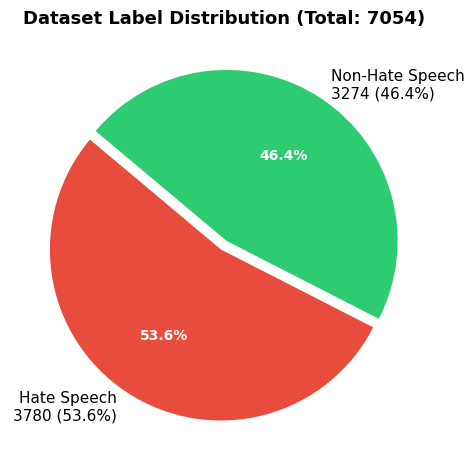

fig1.png saved.


In [7]:
fig, ax = plt.subplots(figsize=(5, 5))
sizes   = [hate_count, nohate_count]
labels  = [f'Hate Speech\n{hate_count} ({hate_count/total*100:.1f}%)',
            f'Non-Hate Speech\n{nohate_count} ({nohate_count/total*100:.1f}%)']
colors  = ['#E74C3C', '#2ECC71']
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors, explode=(0.03,0.03),
    autopct='%1.1f%%', startangle=140, textprops={'fontsize':11}
)
for at in autotexts:
    at.set_fontsize(10); at.set_color('white'); at.set_fontweight('bold')
ax.set_title(f'Dataset Label Distribution (Total: {total})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig1.png', dpi=300, bbox_inches='tight')
plt.show()
print('fig1.png saved.')

## 6. Load Stopwords

In [8]:
with open(STOPWORDS_PATH, 'r', encoding='utf-8') as f:
    SYLHETI_STOPWORDS = set(
        line.strip().lower() for line in f
        if line.strip() and not line.startswith('#')
    )
print(f'Stopwords loaded: {len(SYLHETI_STOPWORDS)} words')

Stopwords loaded: 157 words


## 7. Data Preprocessing (5 Steps)

In [9]:
def preprocess(text):
    # Step 1: Noise removal
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = text.encode('ascii','ignore').decode('ascii')
    text = re.sub(r"[^a-zA-Z0-9\s\-']", ' ', text)
    # Step 2: Special character cleaning
    text = re.sub(r'[\[\]\(\)\{\}]', ' ', text)
    text = re.sub(r'\s-\s', ' ', text)
    # Step 3: Case folding
    text = text.lower()
    # Step 4: Repeated character reduction
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    # Step 5: Stopword filtering
    tokens = [t for t in text.split() if t not in SYLHETI_STOPWORDS and len(t) > 1]
    return ' '.join(tokens).strip()

df['text_raw']  = df['text']
df['text_prep'] = df['text'].apply(preprocess)

raw_vocab  = set(' '.join(df['text_raw']).split())
prep_vocab = set(' '.join(df['text_prep']).split())
raw_tokens  = len(' '.join(df['text_raw']).split())
prep_tokens = len(' '.join(df['text_prep']).split())

print(f'Vocabulary before: {len(raw_vocab):,}')
print(f'Vocabulary after : {len(prep_vocab):,}')
print(f'Tokens removed   : {raw_tokens - prep_tokens:,}')

Vocabulary before: 16,029
Vocabulary after : 13,053
Tokens removed   : 21,951


## 8. Train / Test Split (80/20 Stratified)

In [10]:
y = df['label'].values

X_raw_train,  X_raw_test,  y_train, y_test = train_test_split(
    df['text_raw'].values, y, test_size=0.2, random_state=42, stratify=y)
X_prep_train, X_prep_test, _,       _      = train_test_split(
    df['text_prep'].values, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train: {len(X_raw_train)}  |  Hate: {y_train.sum()}  Non-hate: {(y_train==0).sum()}')
print(f'Test : {len(X_raw_test)}   |  Hate: {y_test.sum()}   Non-hate: {(y_test==0).sum()}')

Train: 5643  |  Hate: 3024  Non-hate: 2619
Test : 1411   |  Hate: 756   Non-hate: 655


## 9. Vectorizer and Model Definitions

In [11]:
MAX_FEATURES = 50000
DENSE_MODELS = {'GNB'}  # GaussianNB needs dense input

def build_vec(vec_type, analyzer, ngram_range, min_df):
    if vec_type == 'count':
        return CountVectorizer(analyzer=analyzer, ngram_range=ngram_range,
                               min_df=min_df, max_features=MAX_FEATURES)
    return TfidfVectorizer(analyzer=analyzer, ngram_range=ngram_range,
                            min_df=min_df, sublinear_tf=True,
                            max_features=MAX_FEATURES)

def get_models():
    return {
        'LR'        : (LogisticRegression(max_iter=1000, random_state=42),
                       {'C':[0.1,1,10], 'solver':['lbfgs','liblinear']}),
        'SVM'       : (LinearSVC(max_iter=2000, random_state=42),
                       {'C':[0.1,1,10]}),
        'MNB(0.1)'  : (MultinomialNB(alpha=0.1), {}),
        'MNB(1)'    : (MultinomialNB(alpha=1.0),  {}),
        'MNB(10)'   : (MultinomialNB(alpha=10.0), {}),
        'RF'        : (RandomForestClassifier(random_state=42),
                       {'n_estimators':[100], 'max_depth':[None]}),
        'BNB'       : (BernoulliNB(), {'alpha':[0.1,1.0]}),
        'GNB'       : (GaussianNB(), {}),
        'DT'        : (DecisionTreeClassifier(random_state=42),
                       {'max_depth':[None,10], 'criterion':['gini','entropy']}),
        'KNN'       : (KNeighborsClassifier(), {'n_neighbors':[5]}),
    }

def fit_eval(clf, pg, X_tr, X_te, y_tr, y_te):
    clf = copy.deepcopy(clf)
    if pg:
        gs = GridSearchCV(clf, pg, cv=3, scoring='f1_weighted', n_jobs=-1)
        gs.fit(X_tr, y_tr)
        y_pred = gs.best_estimator_.predict(X_te)
    else:
        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_te)
    return {
        'Acc' : round(accuracy_score(y_te, y_pred), 4),
        'Prec': round(precision_score(y_te, y_pred, average='weighted', zero_division=0), 4),
        'Rec' : round(recall_score(y_te, y_pred, average='weighted', zero_division=0), 4),
        'F1'  : round(f1_score(y_te, y_pred, average='weighted', zero_division=0), 4),
    }, y_pred

print('Helpers defined.')

Helpers defined.


## 10. Core Experiment Runner
Runs all models across a given set of configurations. Returns a results DataFrame.

In [12]:
def run_experiments(X_train, X_test, y_train, y_test,
                    vec_type, analyzer, ngram_list, min_df_list,
                    text_type='raw'):
    """
    For a fixed vectorizer type and analyzer, run all models
    across all ngram x min_df combinations.
    Returns a DataFrame with one row per (model, ngram, min_df).
    """
    models  = get_models()
    records = []

    for ngram in ngram_list:
        for min_df in min_df_list:
            vec  = build_vec(vec_type, analyzer, ngram, min_df)
            X_tr = vec.fit_transform(X_train)
            X_te = vec.transform(X_test)
            ngram_label = f'({ngram[0]},{ngram[1]})'

            for mname, (clf, pg) in models.items():
                try:
                    xtr = X_tr.toarray() if mname in DENSE_MODELS else X_tr
                    xte = X_te.toarray() if mname in DENSE_MODELS else X_te
                    res, _ = fit_eval(clf, pg, xtr, xte, y_train, y_test)
                    records.append({
                        'TextType'  : text_type,
                        'Vectorizer': vec_type.upper(),
                        'Analyzer'  : analyzer,
                        'NGram'     : ngram_label,
                        'min_df'    : min_df,
                        'Model'     : mname,
                        **res
                    })
                except Exception as e:
                    pass

    return pd.DataFrame(records)

print('run_experiments() defined.')

run_experiments() defined.


## 11. Run All Experiments
**This is the main computation cell — takes ~20-40 min on Colab CPU.**

In [13]:
WORD_NGRAMS  = [(1,1), (1,2), (1,3)]
CHAR_NGRAMS  = [(2,2), (3,3), (4,4), (5,5)]
MIN_DF_LIST  = [1, 2, 5]

all_results = []

for text_type, X_train, X_test in [
    ('raw',  X_raw_train,  X_raw_test),
    ('prep', X_prep_train, X_prep_test)
]:
    print(f'\n=== Text type: {text_type.upper()} ===')
    for vec_type in ['count', 'tfidf']:
        print(f'  Vectorizer: {vec_type.upper()}')
        print(f'    Word n-grams...')
        df_w = run_experiments(X_train, X_test, y_train, y_test,
                               vec_type, 'word', WORD_NGRAMS, MIN_DF_LIST, text_type)
        all_results.append(df_w)
        print(f'    Char n-grams...')
        df_c = run_experiments(X_train, X_test, y_train, y_test,
                               vec_type, 'char', CHAR_NGRAMS, MIN_DF_LIST, text_type)
        all_results.append(df_c)

results = pd.concat(all_results, ignore_index=True)
results.to_csv(f'{OUTPUT_DIR}/all_results.csv', index=False)
print(f'\nAll experiments done. Total rows: {len(results)}')
print('Saved to all_results.csv')


=== Text type: RAW ===
  Vectorizer: COUNT
    Word n-grams...
    Char n-grams...
  Vectorizer: TFIDF
    Word n-grams...
    Char n-grams...

=== Text type: PREP ===
  Vectorizer: COUNT
    Word n-grams...
    Char n-grams...
  Vectorizer: TFIDF
    Word n-grams...
    Char n-grams...

All experiments done. Total rows: 840
Saved to all_results.csv


## 12. Helper: Best Result per Model per Config

In [14]:
def best_per_model(df_subset):
    """For each model, pick the row with highest F1 across all min_df values."""
    return (
        df_subset
        .sort_values('F1', ascending=False)
        .groupby('Model', sort=False)
        .first()
        .reset_index()
    )

MODEL_ORDER = ['LR','SVM','MNB(0.1)','RF','BNB','MNB(1)','DT','GNB','MNB(10)','KNN']

def sort_models(df):
    df['_order'] = df['Model'].map({m:i for i,m in enumerate(MODEL_ORDER)})
    return df.sort_values('_order').drop(columns='_order').reset_index(drop=True)

print('Helpers ready.')

Helpers ready.


## 13. Table A — CountVectorizer Word N-grams (Raw vs Preprocessed)

In [15]:
# Best F1 per model per ngram under CountVectorizer word-level
tA_raw  = results[(results.Vectorizer=='COUNT') & (results.Analyzer=='word') & (results.TextType=='raw')]
tA_prep = results[(results.Vectorizer=='COUNT') & (results.Analyzer=='word') & (results.TextType=='prep')]

def ngram_pivot(df_subset, metric='F1'):
    """Pivot: rows=Model, cols=NGram, values=metric (best min_df per cell)"""
    best = df_subset.sort_values(metric, ascending=False).groupby(
        ['Model','NGram'], sort=False).first().reset_index()
    pivot = best.pivot(index='Model', columns='NGram', values=metric)
    # reorder columns
    cols = ['(1,1)','(1,2)','(1,3)']
    pivot = pivot[[c for c in cols if c in pivot.columns]]
    pivot.columns = ['Unigram','Bigram','Trigram']
    return pivot

print('=== Table A: CountVectorizer Word N-grams — Best F1 per Model per N-gram ===')
print('--- RAW TEXT ---')
pA_raw = ngram_pivot(tA_raw)
print(pA_raw.round(4).to_string())
print('--- PREPROCESSED TEXT ---')
pA_prep = ngram_pivot(tA_prep)
print(pA_prep.round(4).to_string())
print()

# Save combined
pA_raw.round(4).to_csv(f'{OUTPUT_DIR}/tableA_CV_word_raw.csv')
pA_prep.round(4).to_csv(f'{OUTPUT_DIR}/tableA_CV_word_prep.csv')
print('Table A saved.')

=== Table A: CountVectorizer Word N-grams — Best F1 per Model per N-gram ===
--- RAW TEXT ---
          Unigram  Bigram  Trigram
Model                             
BNB        0.7976  0.7831   0.7824
DT         0.7473  0.7345   0.7395
GNB        0.7638  0.7286   0.7250
KNN        0.6731  0.6306   0.6456
LR         0.8017  0.7904   0.7897
MNB(0.1)   0.7995  0.7830   0.7840
MNB(1)     0.8065  0.7910   0.7942
MNB(10)    0.7750  0.7720   0.7728
RF         0.7658  0.7607   0.7675
SVM        0.8018  0.7919   0.7946
--- PREPROCESSED TEXT ---
          Unigram  Bigram  Trigram
Model                             
BNB        0.8032  0.8074   0.8171
DT         0.7721  0.7586   0.7601
GNB        0.7572  0.7282   0.7337
KNN        0.6786  0.6711   0.6711
LR         0.7990  0.7961   0.7996
MNB(0.1)   0.7960  0.7945   0.7924
MNB(1)     0.7942  0.7921   0.7898
MNB(10)    0.7493  0.7461   0.7469
RF         0.7961  0.7883   0.7855
SVM        0.8011  0.7968   0.7989

Table A saved.


## 14. Table B — TF-IDF Word N-grams (Raw vs Preprocessed)

In [16]:
tB_raw  = results[(results.Vectorizer=='TFIDF') & (results.Analyzer=='word') & (results.TextType=='raw')]
tB_prep = results[(results.Vectorizer=='TFIDF') & (results.Analyzer=='word') & (results.TextType=='prep')]

print('=== Table B: TF-IDF Word N-grams — Best F1 per Model per N-gram ===')
print('--- RAW TEXT ---')
pB_raw = ngram_pivot(tB_raw)
print(pB_raw.round(4).to_string())
print('--- PREPROCESSED TEXT ---')
pB_prep = ngram_pivot(tB_prep)
print(pB_prep.round(4).to_string())

pB_raw.round(4).to_csv(f'{OUTPUT_DIR}/tableB_TFIDF_word_raw.csv')
pB_prep.round(4).to_csv(f'{OUTPUT_DIR}/tableB_TFIDF_word_prep.csv')
print('Table B saved.')

=== Table B: TF-IDF Word N-grams — Best F1 per Model per N-gram ===
--- RAW TEXT ---
          Unigram  Bigram  Trigram
Model                             
BNB        0.7976  0.7831   0.7824
DT         0.7190  0.7182   0.7190
GNB        0.7634  0.7374   0.7365
KNN        0.7486  0.7255   0.5630
LR         0.7845  0.7893   0.7879
MNB(0.1)   0.7999  0.7898   0.7860
MNB(1)     0.7964  0.7848   0.7856
MNB(10)    0.7421  0.7425   0.7418
RF         0.7564  0.7628   0.7550
SVM        0.7845  0.7915   0.7900
--- PREPROCESSED TEXT ---
          Unigram  Bigram  Trigram
Model                             
BNB        0.8032  0.8074   0.8171
DT         0.7493  0.7465   0.7577
GNB        0.7642  0.7337   0.7363
KNN        0.5958  0.6163   0.6242
LR         0.7947  0.7883   0.7883
MNB(0.1)   0.7892  0.7898   0.7907
MNB(1)     0.7879  0.7833   0.7826
MNB(10)    0.7144  0.7171   0.7171
RF         0.7834  0.7847   0.7883
SVM        0.7961  0.7878   0.7877
Table B saved.


## 15. Table C — CountVectorizer Character N-grams

In [17]:
def char_pivot(df_subset, metric='F1'):
    best = df_subset.sort_values(metric, ascending=False).groupby(
        ['Model','NGram'], sort=False).first().reset_index()
    pivot = best.pivot(index='Model', columns='NGram', values=metric)
    cols = ['(2,2)','(3,3)','(4,4)','(5,5)']
    pivot = pivot[[c for c in cols if c in pivot.columns]]
    pivot.columns = [f'Char-{c[1]}' for c in pivot.columns]
    return pivot

tC_raw  = results[(results.Vectorizer=='COUNT') & (results.Analyzer=='char') & (results.TextType=='raw')]
tC_prep = results[(results.Vectorizer=='COUNT') & (results.Analyzer=='char') & (results.TextType=='prep')]

print('=== Table C: CountVectorizer Char N-grams — Best F1 per Model per N ===')
print('--- RAW ---')
pC_raw = char_pivot(tC_raw)
print(pC_raw.round(4).to_string())
print('--- PREPROCESSED ---')
pC_prep = char_pivot(tC_prep)
print(pC_prep.round(4).to_string())

pC_raw.round(4).to_csv(f'{OUTPUT_DIR}/tableC_CV_char_raw.csv')
pC_prep.round(4).to_csv(f'{OUTPUT_DIR}/tableC_CV_char_prep.csv')
print('Table C saved.')

=== Table C: CountVectorizer Char N-grams — Best F1 per Model per N ===
--- RAW ---
          Char-2  Char-3  Char-4  Char-5
Model                                   
BNB       0.6836  0.7704  0.7978  0.8130
DT        0.6731  0.7175  0.7566  0.7739
GNB       0.5330  0.6397  0.7718  0.7799
KNN       0.6594  0.6783  0.5823  0.5424
LR        0.7569  0.7959  0.8201  0.8245
MNB(0.1)  0.7298  0.7988  0.8109  0.8123
MNB(1)    0.7289  0.8022  0.8142  0.8102
MNB(10)   0.7245  0.7899  0.8050  0.7999
RF        0.7494  0.7945  0.8170  0.8188
SVM       0.7476  0.7902  0.8101  0.8039
--- PREPROCESSED ---
          Char-2  Char-3  Char-4  Char-5
Model                                   
BNB       0.7395  0.7967  0.8171  0.8068
DT        0.6998  0.7431  0.7676  0.7780
GNB       0.5475  0.6311  0.7572  0.7565
KNN       0.7103  0.6838  0.6184  0.5851
LR        0.7395  0.8039  0.8294  0.8223
MNB(0.1)  0.7226  0.7873  0.8018  0.7954
MNB(1)    0.7231  0.7901  0.8030  0.7929
MNB(10)   0.7179  0.7771  0.7789  

## 16. Table D — TF-IDF Character N-grams

In [18]:
tD_raw  = results[(results.Vectorizer=='TFIDF') & (results.Analyzer=='char') & (results.TextType=='raw')]
tD_prep = results[(results.Vectorizer=='TFIDF') & (results.Analyzer=='char') & (results.TextType=='prep')]

print('=== Table D: TF-IDF Char N-grams — Best F1 per Model per N ===')
print('--- RAW ---')
pD_raw = char_pivot(tD_raw)
print(pD_raw.round(4).to_string())
print('--- PREPROCESSED ---')
pD_prep = char_pivot(tD_prep)
print(pD_prep.round(4).to_string())

pD_raw.round(4).to_csv(f'{OUTPUT_DIR}/tableD_TFIDF_char_raw.csv')
pD_prep.round(4).to_csv(f'{OUTPUT_DIR}/tableD_TFIDF_char_prep.csv')
print('Table D saved.')

=== Table D: TF-IDF Char N-grams — Best F1 per Model per N ===
--- RAW ---
          Char-2  Char-3  Char-4  Char-5
Model                                   
BNB       0.6836  0.7704  0.7978  0.8130
DT        0.6737  0.7023  0.7591  0.7718
GNB       0.5380  0.6935  0.7629  0.7769
KNN       0.7003  0.7437  0.3230  0.3738
LR        0.7641  0.8079  0.8258  0.8235
MNB(0.1)  0.7140  0.8026  0.8097  0.8145
MNB(1)    0.7151  0.7936  0.8059  0.8006
MNB(10)   0.6465  0.6914  0.7306  0.7443
RF        0.7350  0.7820  0.8051  0.8160
SVM       0.7677  0.8095  0.8279  0.8257
--- PREPROCESSED ---
          Char-2  Char-3  Char-4  Char-5
Model                                   
BNB       0.7395  0.7967  0.8171  0.8068
DT        0.6742  0.7177  0.7723  0.7805
GNB       0.5700  0.6950  0.7473  0.7728
KNN       0.5724  0.3885  0.3622  0.4083
LR        0.7536  0.8081  0.8216  0.8272
MNB(0.1)  0.7125  0.7955  0.8005  0.8091
MNB(1)    0.7126  0.7888  0.7937  0.7944
MNB(10)   0.6602  0.6865  0.7063  0.7218
RF

## 17. Table E — Summary: Best per Model under CV vs TF-IDF (Preprocessed)

In [19]:
# Best F1 per model under CountVectorizer (any ngram, any min_df)
best_cv   = results[(results.Vectorizer=='COUNT') & (results.TextType=='prep')]\
             .sort_values('F1',ascending=False)\
             .groupby('Model').first().reset_index()[['Model','Acc','Prec','Rec','F1']]
best_cv.columns = ['Model','CV_Acc','CV_Prec','CV_Rec','CV_F1']

best_tfidf = results[(results.Vectorizer=='TFIDF') & (results.TextType=='prep')]\
              .sort_values('F1',ascending=False)\
              .groupby('Model').first().reset_index()[['Model','Acc','Prec','Rec','F1']]
best_tfidf.columns = ['Model','TF_Acc','TF_Prec','TF_Rec','TF_F1']

tableE = best_cv.merge(best_tfidf, on='Model')
tableE['Best_Vec'] = tableE.apply(
    lambda r: 'TF-IDF' if r['TF_F1'] >= r['CV_F1'] else 'COUNT', axis=1)
tableE = tableE.sort_values('TF_F1', ascending=False)

print('=== Table E: Summary CV vs TF-IDF — Preprocessed Text ===')
print(tableE.round(4).to_string(index=False))
tableE.round(4).to_csv(f'{OUTPUT_DIR}/tableE_summary_CV_vs_TFIDF.csv', index=False)
print('Table E saved.')

=== Table E: Summary CV vs TF-IDF — Preprocessed Text ===
   Model  CV_Acc  CV_Prec  CV_Rec  CV_F1  TF_Acc  TF_Prec  TF_Rec  TF_F1 Best_Vec
     SVM  0.8214   0.8219  0.8214 0.8215  0.8278   0.8291  0.8278 0.8280   TF-IDF
      LR  0.8292   0.8313  0.8292 0.8294  0.8271   0.8279  0.8271 0.8272    COUNT
      RF  0.8108   0.8125  0.8108 0.8110  0.8172   0.8170  0.8172 0.8171   TF-IDF
     BNB  0.8172   0.8171  0.8172 0.8171  0.8172   0.8171  0.8172 0.8171   TF-IDF
MNB(0.1)  0.8030   0.8046  0.8030 0.8018  0.8101   0.8113  0.8101 0.8091   TF-IDF
  MNB(1)  0.8037   0.8041  0.8037 0.8030  0.7959   0.7981  0.7959 0.7944    COUNT
      DT  0.7782   0.7780  0.7782 0.7780  0.7803   0.7809  0.7803 0.7805   TF-IDF
     GNB  0.7569   0.7598  0.7569 0.7572  0.7725   0.7744  0.7725 0.7728   TF-IDF
 MNB(10)  0.7888   0.7912  0.7888 0.7871  0.7378   0.7793  0.7378 0.7218    COUNT
     KNN  0.7101   0.7107  0.7101 0.7103  0.6343   0.6716  0.6343 0.6242    COUNT
Table E saved.


## 18. Table F — Final Results: Best Config per Model, Raw vs Preprocessed
*(This is the main paper Table II)*

In [20]:
best_raw  = results[results.TextType=='raw']\
             .sort_values('F1',ascending=False)\
             .groupby('Model').first().reset_index()[['Model','Acc','Prec','Rec','F1']]
best_raw.columns = ['Model','Raw_Acc','Raw_Prec','Raw_Rec','Raw_F1']

best_prep = results[results.TextType=='prep']\
             .sort_values('F1',ascending=False)\
             .groupby('Model').first().reset_index()[['Model','Acc','Prec','Rec','F1']]
best_prep.columns = ['Model','Prep_Acc','Prep_Prec','Prep_Rec','Prep_F1']

tableF = best_raw.merge(best_prep, on='Model')
tableF['Delta_F1'] = (tableF['Prep_F1'] - tableF['Raw_F1']).round(4)
tableF = tableF.sort_values('Prep_F1', ascending=False).reset_index(drop=True)

print('=== Table F: Final Results — Raw vs Preprocessed (Paper Table II) ===')
print(f'{"Model":<12} | {"Raw":^30} | {"Prep":^30} | Delta')
print(f'{"":12} | {"Acc":>6} {"Prec":>6} {"Rec":>6} {"F1":>6} | {"Acc":>6} {"Prec":>6} {"Rec":>6} {"F1":>6} | F1')
print('-'*85)
for _,r in tableF.iterrows():
    print(f'{r.Model:<12} | {r.Raw_Acc:>6.4f} {r.Raw_Prec:>6.4f} {r.Raw_Rec:>6.4f} {r.Raw_F1:>6.4f} | '
          f'{r.Prep_Acc:>6.4f} {r.Prep_Prec:>6.4f} {r.Prep_Rec:>6.4f} {r.Prep_F1:>6.4f} | {r.Delta_F1:>+.4f}')
tableF.round(4).to_csv(f'{OUTPUT_DIR}/tableF_final_results.csv', index=False)
print('\nTable F saved.')

=== Table F: Final Results — Raw vs Preprocessed (Paper Table II) ===
Model        |              Raw               |              Prep              | Delta
             |    Acc   Prec    Rec     F1 |    Acc   Prec    Rec     F1 | F1
-------------------------------------------------------------------------------------
LR           | 0.8257 0.8260 0.8257 0.8258 | 0.8292 0.8313 0.8292 0.8294 | +0.0036
SVM          | 0.8278 0.8285 0.8278 0.8279 | 0.8278 0.8291 0.8278 0.8280 | +0.0001
RF           | 0.8186 0.8205 0.8186 0.8188 | 0.8172 0.8170 0.8172 0.8171 | -0.0017
BNB          | 0.8136 0.8140 0.8136 0.8130 | 0.8172 0.8171 0.8172 0.8171 | +0.0041
MNB(0.1)     | 0.8150 0.8152 0.8150 0.8145 | 0.8101 0.8113 0.8101 0.8091 | -0.0054
MNB(1)       | 0.8150 0.8159 0.8150 0.8142 | 0.8037 0.8041 0.8037 0.8030 | -0.0112
MNB(10)      | 0.8065 0.8094 0.8065 0.8050 | 0.7888 0.7912 0.7888 0.7871 | -0.0179
DT           | 0.7739 0.7739 0.7739 0.7739 | 0.7803 0.7809 0.7803 0.7805 | +0.0066
GNB          | 

## 18b. Stopword List AblationAddresses reviewer concern that the 157-word custom stopword list is claimedas a contribution but never tested in isolation. Reruns the overall bestconfiguration (from Table F) with stopword filtering turned OFF, holdingevery other preprocessing step identical, and reports the F1 delta.

In [21]:
def preprocess_no_stopwords(text):
    # Identical to preprocess() in Section 7, EXCEPT step 5 (stopword filtering) is skipped
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r"[^a-zA-Z0-9\s\-']", ' ', text)
    text = re.sub(r'[\[\]\(\)\{\}]', ' ', text)
    text = re.sub(r'\s-\s', ' ', text)
    text = text.lower()
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    tokens = [t for t in text.split() if len(t) > 1]  # <-- stopwords NOT removed here
    return ' '.join(tokens).strip()

df['text_nostop'] = df['text'].apply(preprocess_no_stopwords)
X_nostop_train, X_nostop_test, _, _ = train_test_split(
    df['text_nostop'].values, y, test_size=0.2, random_state=42, stratify=y)

# Best overall configuration, taken from the full sweep in `results`
best_row = results[results.TextType == 'prep'].sort_values('F1', ascending=False).iloc[0]
best_model_name = best_row['Model']
best_vec_type   = best_row['Vectorizer'].lower()
best_analyzer   = best_row['Analyzer']
best_ngram      = tuple(int(x) for x in best_row['NGram'].strip('()').split(','))
best_min_df     = int(best_row['min_df'])

print(f'Best config: {best_model_name} | {best_vec_type} | {best_analyzer} '
      f'| ngram={best_ngram} | min_df={best_min_df}')
print(f'WITH stopword removal    : F1 = {best_row["F1"]:.4f}  (Table F result)')

clf, pg = get_models()[best_model_name]
vec = build_vec(best_vec_type, best_analyzer, best_ngram, best_min_df)
Xtr = vec.fit_transform(X_nostop_train)
Xte = vec.transform(X_nostop_test)
if best_model_name in DENSE_MODELS:
    Xtr, Xte = Xtr.toarray(), Xte.toarray()
res_nostop, _ = fit_eval(clf, pg, Xtr, Xte, y_train, y_test)

print(f'WITHOUT stopword removal : F1 = {res_nostop["F1"]:.4f}')
print(f'Delta F1 (stopword list contribution): {best_row["F1"] - res_nostop["F1"]:+.4f}')

ablation_df = pd.DataFrame([
    {'Condition': 'With stopword list',    'F1': best_row['F1']},
    {'Condition': 'Without stopword list', 'F1': res_nostop['F1']},
])
ablation_df.to_csv(f'{OUTPUT_DIR}/stopword_ablation.csv', index=False)
print('\nSaved to stopword_ablation.csv')

Best config: LR | count | char | ngram=(4, 4) | min_df=2
WITH stopword removal    : F1 = 0.8294  (Table F result)
WITHOUT stopword removal : F1 = 0.8159
Delta F1 (stopword list contribution): +0.0135

Saved to stopword_ablation.csv


## 19. Figure 2 — Accuracy Comparison: Raw vs Preprocessed (fig2.png)

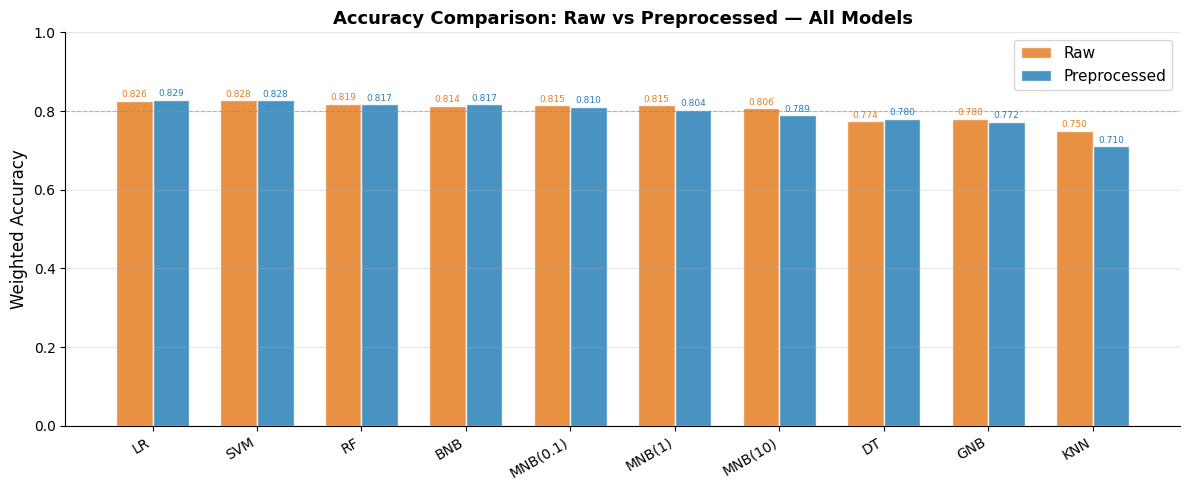

fig2.png saved.


In [22]:
model_order_f = tableF['Model'].tolist()
x = np.arange(len(model_order_f))
w = 0.35
fig, ax = plt.subplots(figsize=(12,5))
b1 = ax.bar(x-w/2, tableF['Raw_Acc'],  w, label='Raw',          color='#E67E22', alpha=0.85, edgecolor='white')
b2 = ax.bar(x+w/2, tableF['Prep_Acc'], w, label='Preprocessed', color='#2980B9', alpha=0.85, edgecolor='white')
for b in b1:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.004, f'{b.get_height():.3f}',
            ha='center', va='bottom', fontsize=6.5, color='#E67E22')
for b in b2:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.004, f'{b.get_height():.3f}',
            ha='center', va='bottom', fontsize=6.5, color='#2980B9')
ax.set_xticks(x); ax.set_xticklabels(model_order_f, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Weighted Accuracy', fontsize=12)
ax.set_title('Accuracy Comparison: Raw vs Preprocessed — All Models', fontsize=13, fontweight='bold')
ax.set_ylim(0,1.0); ax.axhline(0.8, color='gray', linestyle='--', lw=0.8, alpha=0.5)
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig2.png', dpi=300, bbox_inches='tight')
plt.show(); print('fig2.png saved.')

## 20. Figure 3 — F1-Score Comparison: Raw vs Preprocessed (fig3.png)

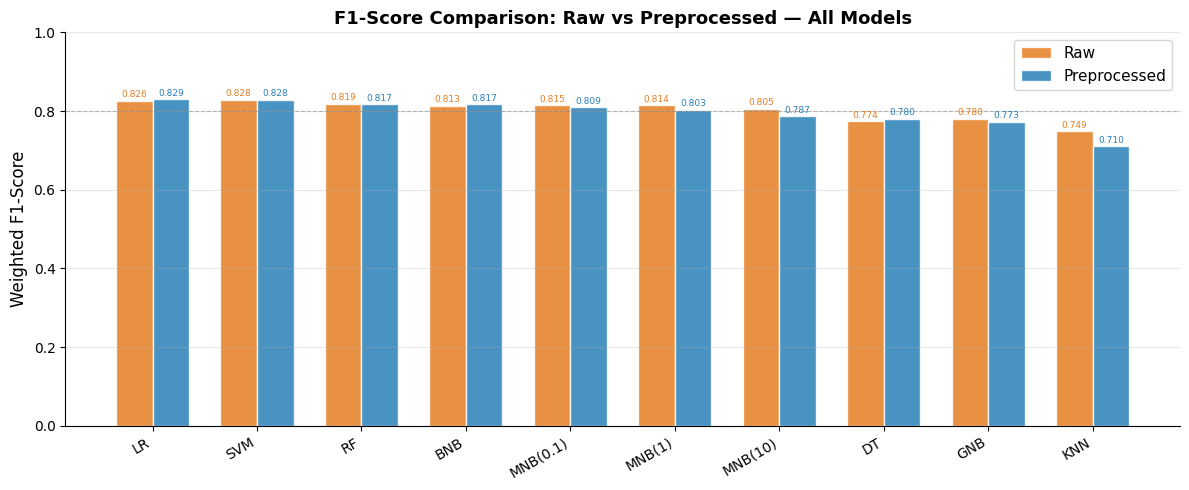

fig3.png saved.


In [23]:
fig, ax = plt.subplots(figsize=(12,5))
b1 = ax.bar(x-w/2, tableF['Raw_F1'],  w, label='Raw',          color='#E67E22', alpha=0.85, edgecolor='white')
b2 = ax.bar(x+w/2, tableF['Prep_F1'], w, label='Preprocessed', color='#2980B9', alpha=0.85, edgecolor='white')
for b in b1:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.004, f'{b.get_height():.3f}',
            ha='center', va='bottom', fontsize=6.5, color='#E67E22')
for b in b2:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.004, f'{b.get_height():.3f}',
            ha='center', va='bottom', fontsize=6.5, color='#2980B9')
ax.set_xticks(x); ax.set_xticklabels(model_order_f, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Weighted F1-Score', fontsize=12)
ax.set_title('F1-Score Comparison: Raw vs Preprocessed — All Models', fontsize=13, fontweight='bold')
ax.set_ylim(0,1.0); ax.axhline(0.8, color='gray', linestyle='--', lw=0.8, alpha=0.5)
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig3.png', dpi=300, bbox_inches='tight')
plt.show(); print('fig3.png saved.')

## 21. Figure 4 — CountVectorizer Word N-gram Accuracy
*(Grouped bar chart style matching Eshan & Hasan 2017)*
- X-axis: N-gram configuration (Unigram, Bigram, Trigram)
- Y-axis: Accuracy (%)
- One bar group per n-gram, one bar per model
- Hatching patterns to distinguish models (no solid colors)

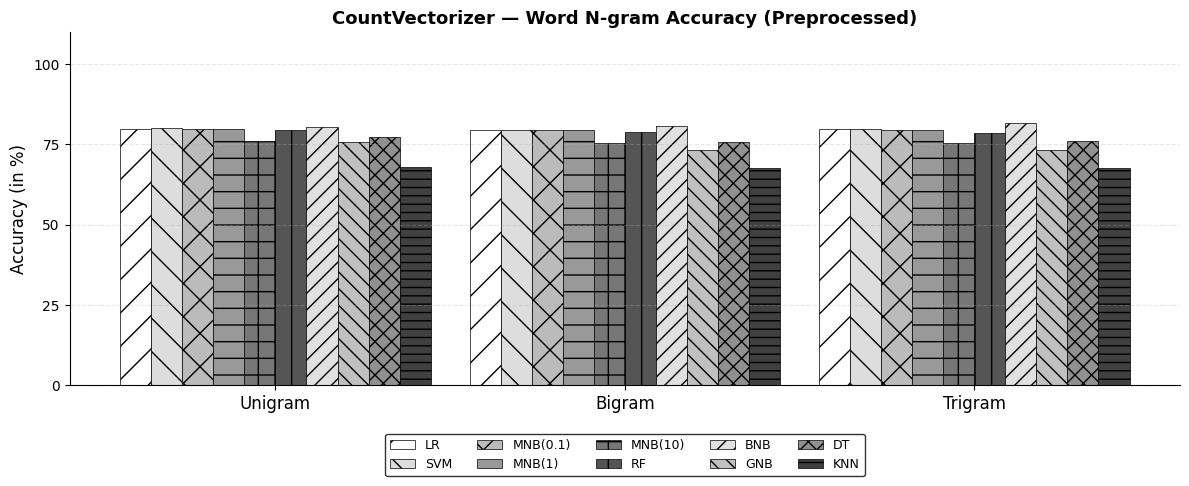

fig4.png saved.


In [24]:
# ── Figure 4: CV Word N-gram Grouped Bar Chart (Eshan & Hasan style) ──────
cv_word_prep = results[
    (results.Vectorizer=='COUNT') &
    (results.Analyzer=='word') &
    (results.TextType=='prep')
]

# Best accuracy per model per ngram (best min_df per cell)
cv_best = (
    cv_word_prep
    .sort_values('Acc', ascending=False)
    .groupby(['Model','NGram'], sort=False)
    .first()
    .reset_index()
)

ngram_keys   = ['(1,1)', '(1,2)', '(1,3)']
ngram_labels = ['Unigram', 'Bigram', 'Trigram']
model_list   = ['LR','SVM','MNB(0.1)','MNB(1)','MNB(10)','RF','BNB','GNB','DT','KNN']

# Hatching patterns — one per model, matching Eshan & Hasan style
hatches = ['/', '\\', 'x', '-', '+', '|', '//', '\\\\', 'xx', '--']
# Grayscale colors (light to dark) — matching their black/white style
grays   = ['#FFFFFF','#DDDDDD','#BBBBBB','#999999','#777777',
           '#555555','#E0E0E0','#C0C0C0','#909090','#404040']

n_models = len(model_list)
n_groups = len(ngram_keys)
bar_w    = 0.08          # width of each bar
group_w  = bar_w * n_models + 0.1  # total group width
group_centres = np.arange(n_groups) * group_w

fig, ax = plt.subplots(figsize=(12, 5))

for i, mname in enumerate(model_list):
    accs = []
    for nk in ngram_keys:
        row = cv_best[(cv_best.Model==mname) & (cv_best.NGram==nk)]
        accs.append(row['Acc'].values[0]*100 if len(row)>0 else 0)

    x_pos = group_centres + (i - n_models/2 + 0.5) * bar_w
    ax.bar(
        x_pos, accs, bar_w,
        label=mname,
        color=grays[i],
        hatch=hatches[i],
        edgecolor='black',
        linewidth=0.5
    )

ax.set_xticks(group_centres)
ax.set_xticklabels(ngram_labels, fontsize=12)
ax.set_ylabel('Accuracy (in %)', fontsize=12)
ax.set_ylim(0, 110)
ax.set_yticks([0, 25, 50, 75, 100])
ax.set_title('CountVectorizer — Word N-gram Accuracy (Preprocessed)',
             fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend below chart — matching Eshan & Hasan layout
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    ncol=5,
    fontsize=9,
    frameon=True,
    edgecolor='black'
)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig4.png', dpi=300, bbox_inches='tight')
plt.show()
print('fig4.png saved.')

## 22. Figure 5 — TF-IDF Word N-gram Accuracy
*(Grouped bar chart style matching Eshan & Hasan 2017)*

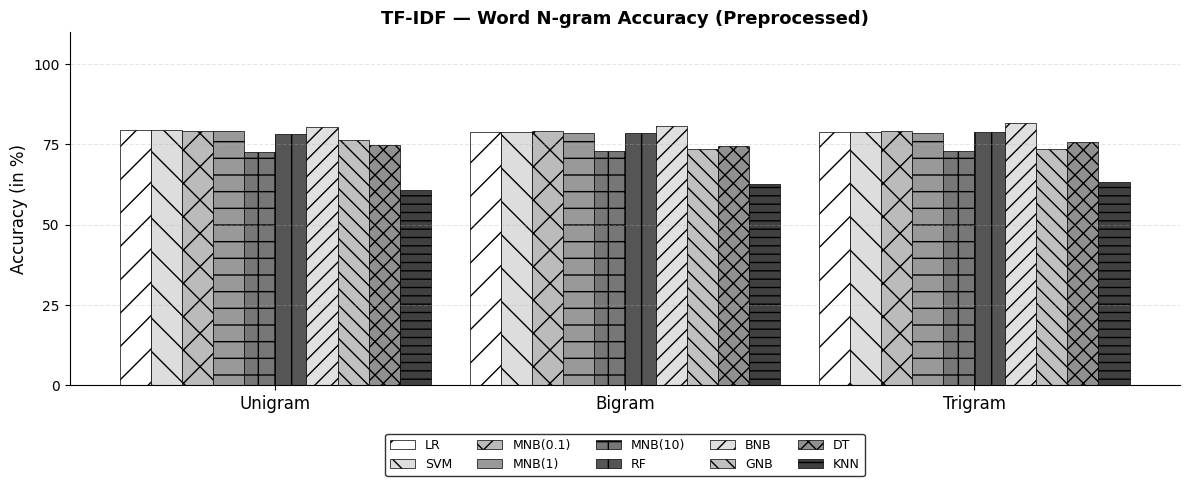

fig5.png saved.


In [25]:
# ── Figure 5: TF-IDF Word N-gram Grouped Bar Chart (Eshan & Hasan style) ──
tfidf_word_prep = results[
    (results.Vectorizer=='TFIDF') &
    (results.Analyzer=='word') &
    (results.TextType=='prep')
]

tf_best = (
    tfidf_word_prep
    .sort_values('Acc', ascending=False)
    .groupby(['Model','NGram'], sort=False)
    .first()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))

for i, mname in enumerate(model_list):
    accs = []
    for nk in ngram_keys:
        row = tf_best[(tf_best.Model==mname) & (tf_best.NGram==nk)]
        accs.append(row['Acc'].values[0]*100 if len(row)>0 else 0)

    x_pos = group_centres + (i - n_models/2 + 0.5) * bar_w
    ax.bar(
        x_pos, accs, bar_w,
        label=mname,
        color=grays[i],
        hatch=hatches[i],
        edgecolor='black',
        linewidth=0.5
    )

ax.set_xticks(group_centres)
ax.set_xticklabels(ngram_labels, fontsize=12)
ax.set_ylabel('Accuracy (in %)', fontsize=12)
ax.set_ylim(0, 110)
ax.set_yticks([0, 25, 50, 75, 100])
ax.set_title('TF-IDF — Word N-gram Accuracy (Preprocessed)',
             fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    ncol=5,
    fontsize=9,
    frameon=True,
    edgecolor='black'
)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig5.png', dpi=300, bbox_inches='tight')
plt.show()
print('fig5.png saved.')

## 23. Figure 6 — Character N-gram Accuracy: CV vs TF-IDF
*(Grouped bar chart style matching Eshan & Hasan 2017)*

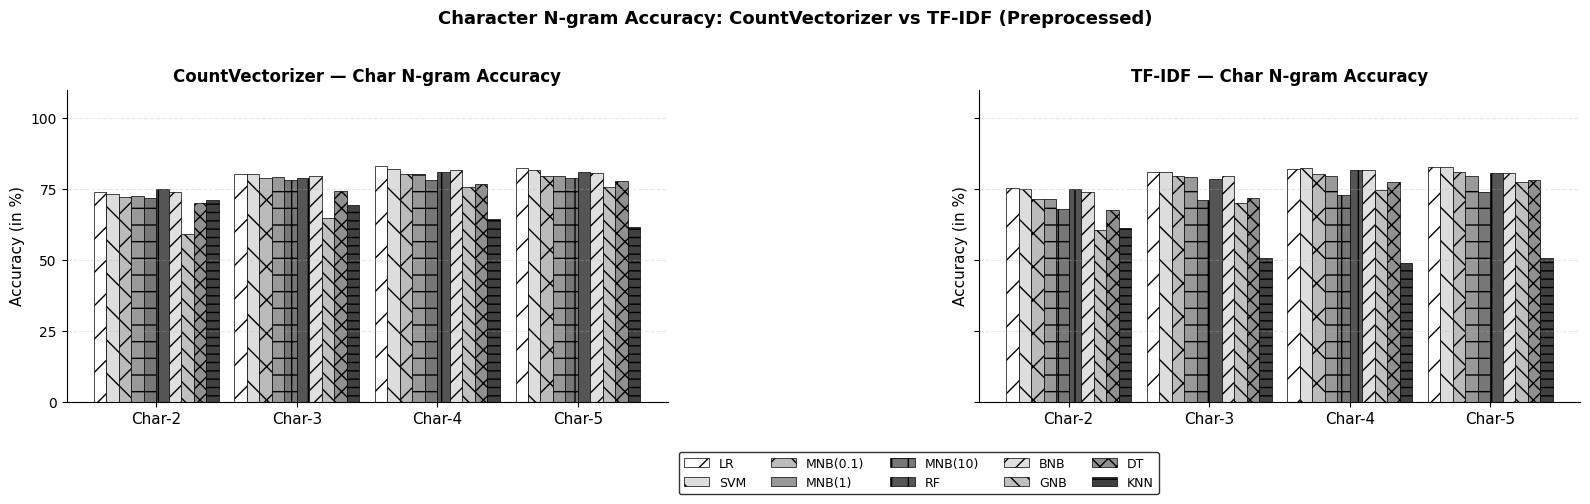

fig6.png saved.


In [26]:
# ── Figure 6: Char N-gram Grouped Bar Chart — CV vs TF-IDF ────────────────
char_keys   = ['(2,2)', '(3,3)', '(4,4)', '(5,5)']
char_labels = ['Char-2', 'Char-3', 'Char-4', 'Char-5']

n_char_groups = len(char_keys)
char_group_centres = np.arange(n_char_groups) * group_w

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax_idx, (vec, title) in enumerate([
    ('COUNT', 'CountVectorizer — Char N-gram Accuracy'),
    ('TFIDF', 'TF-IDF — Char N-gram Accuracy')
]):
    ax = axes[ax_idx]
    char_subset = results[
        (results.Vectorizer==vec) &
        (results.Analyzer=='char') &
        (results.TextType=='prep')
    ]
    char_best_sub = (
        char_subset
        .sort_values('Acc', ascending=False)
        .groupby(['Model','NGram'], sort=False)
        .first()
        .reset_index()
    )

    for i, mname in enumerate(model_list):
        accs = []
        for ck in char_keys:
            row = char_best_sub[
                (char_best_sub.Model==mname) & (char_best_sub.NGram==ck)
            ]
            accs.append(row['Acc'].values[0]*100 if len(row)>0 else 0)

        x_pos = char_group_centres + (i - n_models/2 + 0.5) * bar_w
        ax.bar(
            x_pos, accs, bar_w,
            label=mname,
            color=grays[i],
            hatch=hatches[i],
            edgecolor='black',
            linewidth=0.5
        )

    ax.set_xticks(char_group_centres)
    ax.set_xticklabels(char_labels, fontsize=11)
    ax.set_ylabel('Accuracy (in %)', fontsize=11)
    ax.set_ylim(0, 110)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if ax_idx == 1:
        ax.legend(
            loc='upper center',
            bbox_to_anchor=(-0.1, -0.14),
            ncol=5,
            fontsize=9,
            frameon=True,
            edgecolor='black'
        )

plt.suptitle(
    'Character N-gram Accuracy: CountVectorizer vs TF-IDF (Preprocessed)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig6.png', dpi=300, bbox_inches='tight')
plt.show()
print('fig6.png saved.')

## 24. Figure 7 — Delta F1: Effect of Preprocessing (fig7.png)

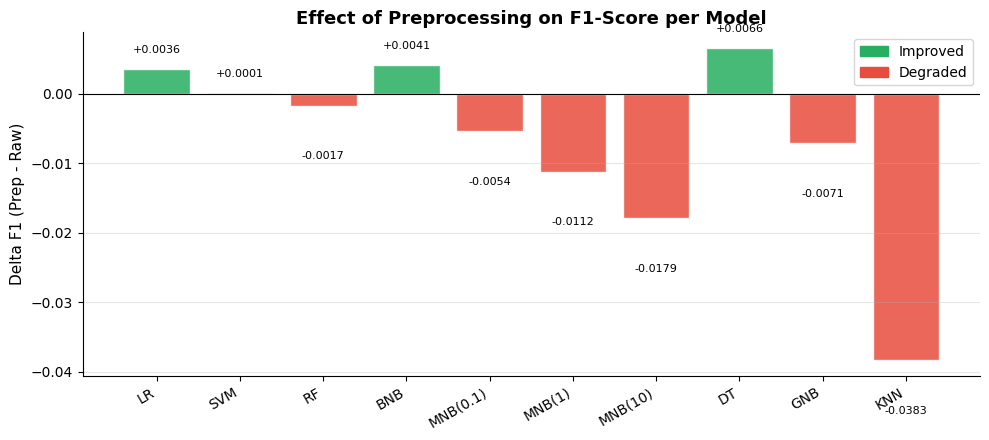

fig7.png saved.


In [27]:
delta_vals = tableF['Delta_F1'].tolist()
colors_d   = ['#27AE60' if d>=0 else '#E74C3C' for d in delta_vals]
fig, ax = plt.subplots(figsize=(10,4.5))
bars = ax.bar(x, delta_vals, color=colors_d, edgecolor='white', alpha=0.85)
for bar, val in zip(bars, delta_vals):
    yp = bar.get_height()+0.002 if val>=0 else bar.get_height()-0.008
    ax.text(bar.get_x()+bar.get_width()/2, yp, f'{val:+.4f}',
            ha='center', va='bottom', fontsize=8)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(model_order_f, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Delta F1 (Prep - Raw)', fontsize=11)
ax.set_title('Effect of Preprocessing on F1-Score per Model', fontsize=13, fontweight='bold')
green_p = mpatches.Patch(color='#27AE60', label='Improved')
red_p   = mpatches.Patch(color='#E74C3C', label='Degraded')
ax.legend(handles=[green_p, red_p], fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig7.png', dpi=300, bbox_inches='tight')
plt.show(); print('fig7.png saved.')

## 25. Figure 8 — Heatmap: All 4 Metrics × All Models, Preprocessed (fig8.png)

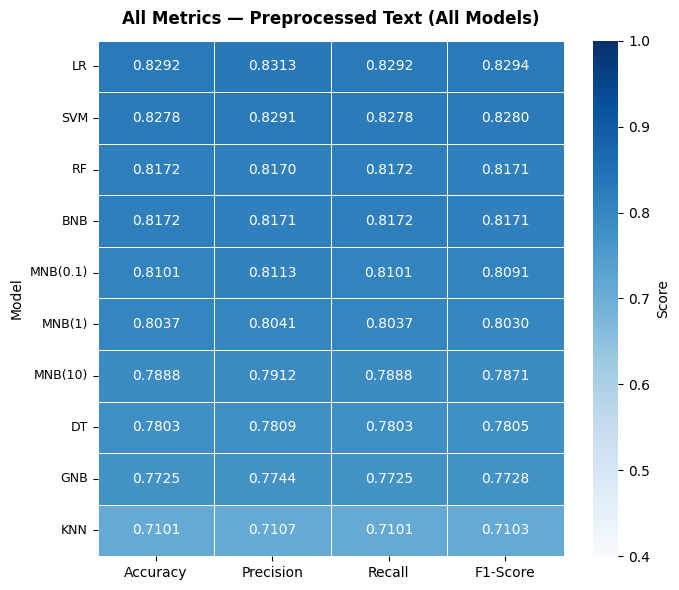

fig8.png saved.


In [28]:
hm_data = tableF.set_index('Model')[['Prep_Acc','Prep_Prec','Prep_Rec','Prep_F1']]
hm_data.columns = ['Accuracy','Precision','Recall','F1-Score']
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(hm_data, annot=True, fmt='.4f', cmap='Blues',
            vmin=0.4, vmax=1.0, linewidths=0.5, linecolor='white',
            ax=ax, cbar_kws={'label':'Score'})
ax.set_title('All Metrics — Preprocessed Text (All Models)',
             fontsize=12, fontweight='bold', pad=12)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=9, rotation=0)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig8.png', dpi=300, bbox_inches='tight')
plt.show(); print('fig8.png saved.')

## 26. Figure 9 — Top 3 Models: Full Metric Comparison (fig9.png)

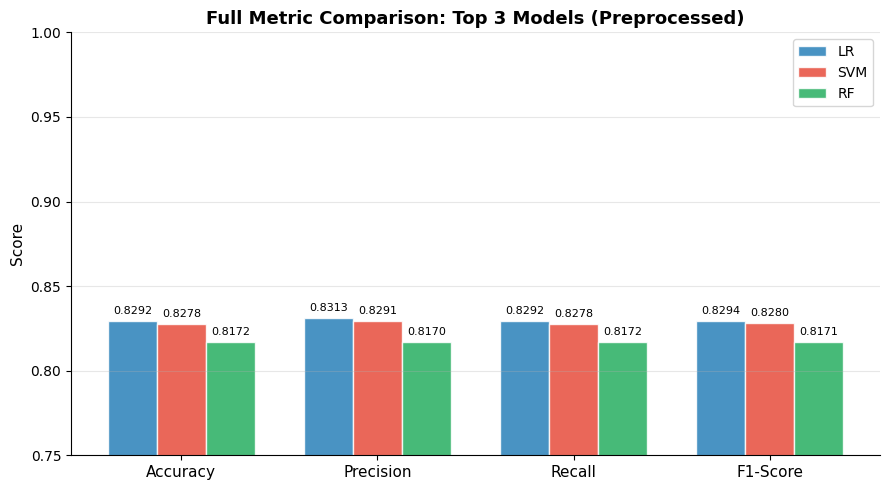

fig9.png saved.


In [29]:
top3    = tableF.head(3)
metrics = ['Prep_Acc','Prep_Prec','Prep_Rec','Prep_F1']
mlabs   = ['Accuracy','Precision','Recall','F1-Score']
x_m     = np.arange(len(mlabs))
width   = 0.25
c3      = ['#2980B9','#E74C3C','#27AE60']
fig, ax = plt.subplots(figsize=(9,5))
for i, (_, row) in enumerate(top3.iterrows()):
    vals = [row[m] for m in metrics]
    bars = ax.bar(x_m+(i-1)*width, vals, width,
                  label=row['Model'], color=c3[i], alpha=0.85, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x_m); ax.set_xticklabels(mlabs, fontsize=11)
ax.set_ylabel('Score', fontsize=11); ax.set_ylim(0.75, 1.0)
ax.set_title('Full Metric Comparison: Top 3 Models (Preprocessed)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig9.png', dpi=300, bbox_inches='tight')
plt.show(); print('fig9.png saved.')

## 27. Confusion Matrix — Best Model

Best model: LR
Best F1: 0.8294
              precision    recall  f1-score   support

Non-Hate (0)       0.80      0.85      0.82       655
    Hate (1)       0.86      0.81      0.84       756

    accuracy                           0.83      1411
   macro avg       0.83      0.83      0.83      1411
weighted avg       0.83      0.83      0.83      1411



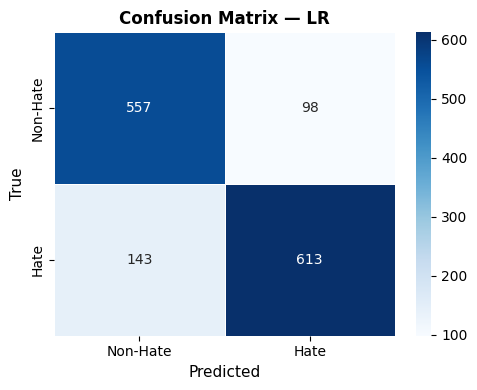

confusion_matrix.png saved.


In [30]:
# Re-run best model to get predictions
best_mname = tableF.iloc[0]['Model']
print(f'Best model: {best_mname}')

models     = get_models()
clf_b, pg_b = models[best_mname]
best_f1_b  = -1
best_pred_b = None

for vec_type in ['count','tfidf']:
    for ngram in [(1,1),(1,2),(1,3),(2,2),(3,3),(4,4),(5,5)]:
        for min_df in [1,2,5]:
            try:
                analyzer = 'char' if ngram[0]==ngram[1] and ngram[0]>=2 else 'word'
                # correct: word ngrams have range start=1, char ngrams have equal values
                if ngram in [(1,1),(1,2),(1,3)]:
                    analyzer = 'word'
                else:
                    analyzer = 'char'
                vec  = build_vec(vec_type, analyzer, ngram, min_df)
                X_tr = vec.fit_transform(X_prep_train)
                X_te = vec.transform(X_prep_test)
                clf_copy = copy.deepcopy(clf_b)
                if best_mname in DENSE_MODELS:
                    X_tr = X_tr.toarray(); X_te = X_te.toarray()
                if pg_b:
                    gs = GridSearchCV(clf_copy, pg_b, cv=3,
                                      scoring='f1_weighted', n_jobs=-1)
                    gs.fit(X_tr, y_train)
                    y_pred_b = gs.best_estimator_.predict(X_te)
                else:
                    clf_copy.fit(X_tr, y_train)
                    y_pred_b = clf_copy.predict(X_te)
                f1_b = f1_score(y_test, y_pred_b, average='weighted')
                if f1_b > best_f1_b:
                    best_f1_b  = f1_b
                    best_pred_b = y_pred_b
            except:
                continue

print(f'Best F1: {best_f1_b:.4f}')
print(classification_report(y_test, best_pred_b,
      target_names=['Non-Hate (0)','Hate (1)']))

cm = confusion_matrix(y_test, best_pred_b)
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Hate','Hate'],
            yticklabels=['Non-Hate','Hate'],
            ax=ax, linewidths=0.5)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True', fontsize=11)
ax.set_title(f'Confusion Matrix — {best_mname}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show(); print('confusion_matrix.png saved.')

## 27b. Repeated Cross-Validation & Significance TestingAddresses reviewer concern about single-split validation. Reports mean ± std F1over repeated stratified k-fold for the top 3 models, and runs McNemar's testto check whether the difference between the top 2 models is statisticallysignificant (not just noise from a single 80/20 split).

In [31]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

# Use the full preprocessed dataset (not just the single train split)
X_full_prep = df['text_prep'].values
y_full = df['label'].values

top3_models = tableF['Model'].head(3).tolist()
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

cv_summary = []
for mname in top3_models:
    # Use each model's best-found configuration (from the full sweep) on preprocessed text
    row = results[(results.Model == mname) & (results.TextType == 'prep')] \
            .sort_values('F1', ascending=False).iloc[0]
    vec_type = row['Vectorizer'].lower()
    analyzer = row['Analyzer']
    ngram    = tuple(int(x) for x in row['NGram'].strip('()').split(','))
    min_df   = int(row['min_df'])

    clf, pg = get_models()[mname]
    vec  = build_vec(vec_type, analyzer, ngram, min_df)
    pipe = Pipeline([('vec', vec), ('clf', copy.deepcopy(clf))])

    scores = cross_val_score(pipe, X_full_prep, y_full, cv=rskf,
                              scoring='f1_weighted', n_jobs=-1)
    cv_summary.append({'Model': mname, 'Mean_F1': round(scores.mean(), 4),
                        'Std_F1': round(scores.std(), 4)})
    print(f'{mname:10s} — 5x3 Repeated CV F1: {scores.mean():.4f} +/- {scores.std():.4f}')

cv_summary_df = pd.DataFrame(cv_summary)
cv_summary_df.to_csv(f'{OUTPUT_DIR}/repeated_cv_summary.csv', index=False)
print('\nSaved to repeated_cv_summary.csv')
print('NOTE: GridSearchCV hyperparameter tuning is skipped inside each CV fold here')
print('for speed. If you need tuned params per fold too, wrap pipe in GridSearchCV')
print('and nest it inside cross_val_score (nested CV) — much slower but more rigorous.')

LR         — 5x3 Repeated CV F1: 0.8254 +/- 0.0071
SVM        — 5x3 Repeated CV F1: 0.8172 +/- 0.0080
RF         — 5x3 Repeated CV F1: 0.8157 +/- 0.0107

Saved to repeated_cv_summary.csv
NOTE: GridSearchCV hyperparameter tuning is skipped inside each CV fold here
for speed. If you need tuned params per fold too, wrap pipe in GridSearchCV
and nest it inside cross_val_score (nested CV) — much slower but more rigorous.


In [32]:
# statsmodels is required for McNemar's test — install if not already present
try:
    from statsmodels.stats.contingency_tables import mcnemar
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'statsmodels', '-q'])
    from statsmodels.stats.contingency_tables import mcnemar

def get_test_predictions(mname):
    """Refit a model's best config on the held-out train/test split and return test predictions."""
    row = results[(results.Model == mname) & (results.TextType == 'prep')] \
            .sort_values('F1', ascending=False).iloc[0]
    vec_type = row['Vectorizer'].lower()
    analyzer = row['Analyzer']
    ngram    = tuple(int(x) for x in row['NGram'].strip('()').split(','))
    min_df   = int(row['min_df'])
    clf, pg  = get_models()[mname]
    vec = build_vec(vec_type, analyzer, ngram, min_df)
    Xtr = vec.fit_transform(X_prep_train)
    Xte = vec.transform(X_prep_test)
    if mname in DENSE_MODELS:
        Xtr, Xte = Xtr.toarray(), Xte.toarray()
    _, y_pred = fit_eval(clf, pg, Xtr, Xte, y_train, y_test)
    return y_pred

model_1, model_2 = tableF.iloc[0]['Model'], tableF.iloc[1]['Model']
pred_1 = get_test_predictions(model_1)
pred_2 = get_test_predictions(model_2)

correct_1 = (pred_1 == y_test)
correct_2 = (pred_2 == y_test)

n_both_correct      = int(( correct_1 &  correct_2).sum())
n_1_correct_2_wrong = int(( correct_1 & ~correct_2).sum())
n_1_wrong_2_correct  = int((~correct_1 &  correct_2).sum())
n_both_wrong         = int((~correct_1 & ~correct_2).sum())

contingency = [[n_both_correct, n_1_correct_2_wrong],
               [n_1_wrong_2_correct, n_both_wrong]]

mcnemar_result = mcnemar(contingency, exact=True)
print(f"McNemar's test: {model_1} vs {model_2}")
print(f'Contingency table (rows={model_1} correct/wrong, cols={model_2} correct/wrong):')
print(pd.DataFrame(contingency,
                    index=[f'{model_1} correct', f'{model_1} wrong'],
                    columns=[f'{model_2} correct', f'{model_2} wrong']))
print(f'\nStatistic = {mcnemar_result.statistic:.4f}, p-value = {mcnemar_result.pvalue:.4f}')
print(f'Significant difference (p < 0.05): {mcnemar_result.pvalue < 0.05}')

McNemar's test: LR vs SVM
Contingency table (rows=LR correct/wrong, cols=SVM correct/wrong):
            SVM correct  SVM wrong
LR correct         1109         61
LR wrong             59        182

Statistic = 59.0000, p-value = 0.9273
Significant difference (p < 0.05): False


## 27c. Transformer Baseline (mBERT)Addresses reviewer request for at least one transformer-based baseline(mBERT, XLM-R, or a Bangla/Sylheti-adapted model) alongside the classicalML models, for a fair comparison against current NLP practice. Uses rawtext (not the stopword-filtered version) since subword tokenizers handletheir own normalization and heavy preprocessing can remove useful signal.**Runtime note:** this fine-tunes a full transformer and will takesignificantly longer than the classical ML cells above (roughly 10-20minutes on a Colab T4 GPU for 4 epochs on ~5,600 training samples).To try XLM-R instead, just change `TRANSFORMER_MODEL` below.

In [33]:
!pip install -q transformers datasets accelerate

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

TRANSFORMER_MODEL = 'bert-base-multilingual-cased'  # swap to 'xlm-roberta-base' to try XLM-R instead
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
print(f'Model: {TRANSFORMER_MODEL}')
if device == 'cpu':
    print('WARNING: no GPU detected. In Colab, go to Runtime > Change runtime type > GPU (T4).')

Using device: cuda
Model: bert-base-multilingual-cased


In [34]:
# Build train/test datasets from RAW text (X_raw_train / X_raw_test, defined in Section 8)
tokenizer = AutoTokenizer.from_pretrained(TRANSFORMER_MODEL)

def tokenize_fn(batch):
    return tokenizer(batch['text'], truncation=True, padding='max_length', max_length=128)

train_ds = Dataset.from_dict({'text': list(X_raw_train), 'label': y_train.tolist()})
test_ds  = Dataset.from_dict({'text': list(X_raw_test),  'label': y_test.tolist()})

train_ds = train_ds.map(tokenize_fn, batched=True)
test_ds  = test_ds.map(tokenize_fn, batched=True)

train_ds = train_ds.remove_columns(['text'])
test_ds  = test_ds.remove_columns(['text'])
train_ds.set_format('torch')
test_ds.set_format('torch')

print(f'Train examples: {len(train_ds)}  |  Test examples: {len(test_ds)}')

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

Map:   0%|          | 0/5643 [00:00<?, ? examples/s]

Map:   0%|          | 0/1411 [00:00<?, ? examples/s]

Train examples: 5643  |  Test examples: 1411


In [38]:
model = AutoModelForSequenceClassification.from_pretrained(TRANSFORMER_MODEL, num_labels=2).to(device)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy' : accuracy_score(labels, preds),
        'f1'       : f1_score(labels, preds, average='weighted'),
        'precision': precision_score(labels, preds, average='weighted', zero_division=0),
        'recall'   : recall_score(labels, preds, average='weighted', zero_division=0),
    }

# NOTE: some transformers versions use `evaluation_strategy` instead of `eval_strategy`.
# If you get a TypeError on this argument, rename it to `evaluation_strategy='epoch'`.
training_args = TrainingArguments(
    output_dir            = f'{OUTPUT_DIR}/transformer_ckpt',
    num_train_epochs      = 4,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size   = 32,
    learning_rate          = 2e-5,
    weight_decay            = 0.01,
    eval_strategy          = 'epoch',
    save_strategy           = 'no',
    logging_steps            = 50,
    seed                     = 42,
    report_to                = 'none',
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_ds,
    eval_dataset    = test_ds,
    compute_metrics = compute_metrics,
)

# Re-install torch and torchvision to resolve potential version conflicts leading to ImportError
# This might be necessary if the pre-installed Colab versions are incompatible with new transformers/datasets.
import subprocess
import sys

print("Attempting to upgrade torch and torchvision to resolve ImportError...")
subprocess.run([sys.executable, '-m', 'pip', 'install', 'torch', 'torchvision', '--upgrade', '-q'])
print("Upgrade command completed. Retrying training.")

# --- FIX: Monkey-patch torchvision.io to prevent VideoReader import ---
# This is a known workaround for ImportError: cannot import name 'VideoReader' from 'torchvision.io'
# when video functionality is not needed, often caused by compatibility issues with the 'datasets' library.
# We delete the problematic attributes from the already loaded 'torchvision.io' module.
try:
    if 'torchvision.io' in sys.modules:
        import torchvision.io
        if hasattr(torchvision.io, '_video_backend'):
            print("Patching torchvision.io: Removing _video_backend to prevent VideoReader import error.")
            delattr(torchvision.io, '_video_backend')
        if hasattr(torchvision.io, '_C'): # _C is the C++ backend VideoReader depends on
            print("Patching torchvision.io: Removing _C to prevent video backend issues.")
            delattr(torchvision.io, '_C')
        # Optionally, remove VideoReader itself if it was partially loaded or cached
        if hasattr(torchvision.io, 'VideoReader'):
            print("Patching torchvision.io: Removing VideoReader attribute.")
            delattr(torchvision.io, 'VideoReader')
except Exception as e:
    print(f"An error occurred during torchvision patching: {e}")
# -------------------------------------------------------------------
import datasets
datasets.config.TORCHVISION_AVAILABLE = False
trainer.train()
transformer_results = trainer.evaluate()
print(transformer_results)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Attempting to upgrade torch and torchvision to resolve ImportError...
Upgrade command completed. Retrying training.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.506843,0.513555,0.769667,0.767995,0.771256,0.769667
2,0.390430,0.445757,0.823529,0.823756,0.825967,0.823529
3,0.300726,0.449761,0.824238,0.824140,0.824124,0.824238
4,0.274295,0.517590,0.823529,0.823374,0.823406,0.823529


Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.274295,0.517590,4,0.823529,0.823374,0.823406,0.823529


{'eval_loss': 0.5175895094871521, 'eval_accuracy': 0.8235294117647058, 'eval_f1': 0.8233741327466048, 'eval_precision': 0.8234060282673381, 'eval_recall': 0.8235294117647058}


In [39]:
transformer_row = pd.DataFrame([{
    'Model': TRANSFORMER_MODEL,
    'Acc' : round(transformer_results['eval_accuracy'], 4),
    'Prec': round(transformer_results['eval_precision'], 4),
    'Rec' : round(transformer_results['eval_recall'], 4),
    'F1'  : round(transformer_results['eval_f1'], 4),
}])

classical_top3 = tableF[['Model','Prep_Acc','Prep_Prec','Prep_Rec','Prep_F1']].head(3).rename(
    columns={'Prep_Acc':'Acc','Prep_Prec':'Prec','Prep_Rec':'Rec','Prep_F1':'F1'})

comparison = pd.concat([transformer_row, classical_top3], ignore_index=True)
print('=== Transformer vs. Top 3 Classical ML Models ===')
print(comparison.to_string(index=False))
comparison.to_csv(f'{OUTPUT_DIR}/transformer_vs_classical.csv', index=False)
print('\nSaved to transformer_vs_classical.csv')
print('If classical ML still wins on this small, code-mixed, romanized dataset,')
print('that itself is a reportable finding worth discussing (not just a negative result).')

=== Transformer vs. Top 3 Classical ML Models ===
                       Model    Acc   Prec    Rec     F1
bert-base-multilingual-cased 0.8235 0.8234 0.8235 0.8234
                          LR 0.8292 0.8313 0.8292 0.8294
                         SVM 0.8278 0.8291 0.8278 0.8280
                          RF 0.8172 0.8170 0.8172 0.8171

Saved to transformer_vs_classical.csv
If classical ML still wins on this small, code-mixed, romanized dataset,
that itself is a reportable finding worth discussing (not just a negative result).


## 28. Figure 10 — Error Analysis (fig10.png)

Total test samples : 1411
Total errors       : 241 (17.08%)
False Positives    : 98  (Non-hate predicted as Hate)
False Negatives    : 143  (Hate predicted as Non-hate)

--- Sample False Positives (5) ---
                                     text  true  predicted
                       mastor tmi hikaiso     0          1
                          porn star model     0          1
desho sangbadik rickshaw alain barigesoin     0          1
                      sundor fuatar brain     0          1
     tumarare bangla pam der tumra bujray     0          1

--- Sample False Negatives (5) ---
                          text  true  predicted
            mura dew shuna gin     1          0
teng bhainga hate dhoraya dimu     1          0
      viral link faa faa soler     1          0
   moja tumio faiso eo faisoin     1          0
    kutta leagueor ekdin oibou     1          0


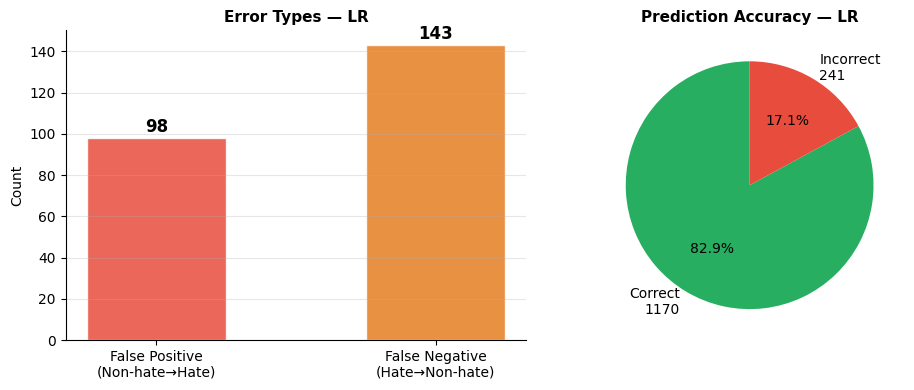

fig10.png saved.


In [40]:
error_df = pd.DataFrame({
    'text'     : X_prep_test,
    'true'     : y_test,
    'predicted': best_pred_b
})
error_df['correct'] = error_df['true'] == error_df['predicted']
errors = error_df[~error_df['correct']]
fp = errors[(errors.true==0) & (errors.predicted==1)]
fn = errors[(errors.true==1) & (errors.predicted==0)]

print(f'Total test samples : {len(error_df)}')
print(f'Total errors       : {len(errors)} ({len(errors)/len(error_df)*100:.2f}%)')
print(f'False Positives    : {len(fp)}  (Non-hate predicted as Hate)')
print(f'False Negatives    : {len(fn)}  (Hate predicted as Non-hate)')
print(f'\n--- Sample False Positives (5) ---')
print(fp[['text','true','predicted']].head(5).to_string(index=False))
print(f'\n--- Sample False Negatives (5) ---')
print(fn[['text','true','predicted']].head(5).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10,4))
# Left: FP vs FN
axes[0].bar(['False Positive\n(Non-hate→Hate)', 'False Negative\n(Hate→Non-hate)'],
            [len(fp), len(fn)],
            color=['#E74C3C','#E67E22'], alpha=0.85, edgecolor='white', width=0.5)
for i, v in enumerate([len(fp), len(fn)]):
    axes[0].text(i, v+1, str(v), ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_title(f'Error Types — {best_mname}', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=10)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)
# Right: correct vs incorrect pie
axes[1].pie([len(error_df)-len(errors), len(errors)],
            labels=[f'Correct\n{len(error_df)-len(errors)}',
                    f'Incorrect\n{len(errors)}'],
            colors=['#27AE60','#E74C3C'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize':10})
axes[1].set_title(f'Prediction Accuracy — {best_mname}', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig10.png', dpi=300, bbox_inches='tight')
plt.show(); print('fig10.png saved.')

## 28b. Qualitative Error Analysis — Categorization ScaffoldAddresses reviewer request for deeper qualitative analysis of misclassifiedexamples (the confusion matrix shows more false negatives than falsepositives). Adds heuristic flags to help you categorize *why* the modelmisses certain hateful comments, and exports both error sets to CSV so youcan hand-annotate 8-10 representative examples for a table in the paper.

In [41]:
# Heuristic flags to help categorize false negatives / false positives.
# These are NOT a substitute for manual review — they just help you triage
# which examples to look at closely for the paper's qualitative discussion.
CODE_MIX_MARKERS = {'is','the','you','are','and','not','what','why','how',
                     'with','for','this','that','was','were','have','has'}

def heuristic_flags(text):
    tokens = str(text).split()
    return pd.Series({
        'n_tokens'           : len(tokens),
        'has_english_marker' : any(t.lower() in CODE_MIX_MARKERS for t in tokens),
        'has_repeated_chars' : bool(re.search(r'(.)\1{2,}', str(text))),
        'is_short'           : len(tokens) <= 3,
    })

fn_annotated = fn.copy().reset_index(drop=True)
fn_annotated = fn_annotated.join(fn_annotated['text'].apply(heuristic_flags))

fp_annotated = fp.copy().reset_index(drop=True)
fp_annotated = fp_annotated.join(fp_annotated['text'].apply(heuristic_flags))

print('=== False Negatives (hate missed by model) — heuristic summary ===')
print(f"Code-mixed (English function word present) : {fn_annotated['has_english_marker'].sum()} / {len(fn_annotated)}")
print(f"Very short (<= 3 tokens)                    : {fn_annotated['is_short'].sum()} / {len(fn_annotated)}")
print(f"Repeated/elongated characters                : {fn_annotated['has_repeated_chars'].sum()} / {len(fn_annotated)}")

print('\n=== False Positives (non-hate flagged as hate) — heuristic summary ===')
print(f"Code-mixed (English function word present) : {fp_annotated['has_english_marker'].sum()} / {len(fp_annotated)}")
print(f"Very short (<= 3 tokens)                    : {fp_annotated['is_short'].sum()} / {len(fp_annotated)}")
print(f"Repeated/elongated characters                : {fp_annotated['has_repeated_chars'].sum()} / {len(fp_annotated)}")

fn_annotated.to_csv(f'{OUTPUT_DIR}/false_negatives_for_manual_review.csv', index=False)
fp_annotated.to_csv(f'{OUTPUT_DIR}/false_positives_for_manual_review.csv', index=False)
print('\nSaved false_negatives_for_manual_review.csv and false_positives_for_manual_review.csv')
print('Next step: open these files, pick 8-10 representative rows each, add a')
print('"category" column by hand (e.g. sarcasm, slur-spelling-variant,')
print('indirect/coded insult, ambiguous-without-context, heavy code-mixing),')
print('then build a short example table for the paper\'s Results/Discussion section.')

=== False Negatives (hate missed by model) — heuristic summary ===
Code-mixed (English function word present) : 1 / 143
Very short (<= 3 tokens)                    : 37 / 143
Repeated/elongated characters                : 0 / 143

=== False Positives (non-hate flagged as hate) — heuristic summary ===
Code-mixed (English function word present) : 1 / 98
Very short (<= 3 tokens)                    : 14 / 98
Repeated/elongated characters                : 0 / 98

Saved false_negatives_for_manual_review.csv and false_positives_for_manual_review.csv
Next step: open these files, pick 8-10 representative rows each, add a
"category" column by hand (e.g. sarcasm, slur-spelling-variant,
indirect/coded insult, ambiguous-without-context, heavy code-mixing),
then build a short example table for the paper's Results/Discussion section.


## 29. Final Summary

In [42]:
print('='*60)
print('FINAL SUMMARY')
print('='*60)
print(f'Dataset          : {total:,} samples')
print(f'  Hate (1)       : {hate_count:,} ({hate_count/total*100:.1f}%)')
print(f'  Non-hate (0)   : {nohate_count:,} ({nohate_count/total*100:.1f}%)')
print(f'Train / Test     : {len(X_raw_train)} / {len(X_raw_test)}')
print()
print(f'Best Model (Prep F1) : {tableF.iloc[0]["Model"]} — {tableF.iloc[0]["Prep_F1"]:.4f}')
print(f'2nd  Model (Prep F1) : {tableF.iloc[1]["Model"]} — {tableF.iloc[1]["Prep_F1"]:.4f}')
print(f'3rd  Model (Prep F1) : {tableF.iloc[2]["Model"]} — {tableF.iloc[2]["Prep_F1"]:.4f}')
print()
print('Output files saved to:', OUTPUT_DIR)
print('  Tables : tableA–tableF (.csv)')
print('  fig1   : Label distribution')
print('  fig2   : Accuracy raw vs prep')
print('  fig3   : F1 raw vs prep')
print('  fig4   : CV word n-gram accuracy trend')
print('  fig5   : TF-IDF word n-gram accuracy trend')
print('  fig6   : Char n-gram CV vs TF-IDF')
print('  fig7   : Delta F1 preprocessing effect')
print('  fig8   : Heatmap all metrics all models')
print('  fig9   : Top 3 models full metrics')
print('  fig10  : Error analysis')
print('  confusion_matrix.png')
print('='*60)

FINAL SUMMARY
Dataset          : 7,054 samples
  Hate (1)       : 3,780 (53.6%)
  Non-hate (0)   : 3,274 (46.4%)
Train / Test     : 5643 / 1411

Best Model (Prep F1) : LR — 0.8294
2nd  Model (Prep F1) : SVM — 0.8280
3rd  Model (Prep F1) : RF — 0.8171

Output files saved to: /content/drive/MyDrive/SylHate/outputs
  Tables : tableA–tableF (.csv)
  fig1   : Label distribution
  fig2   : Accuracy raw vs prep
  fig3   : F1 raw vs prep
  fig4   : CV word n-gram accuracy trend
  fig5   : TF-IDF word n-gram accuracy trend
  fig6   : Char n-gram CV vs TF-IDF
  fig7   : Delta F1 preprocessing effect
  fig8   : Heatmap all metrics all models
  fig9   : Top 3 models full metrics
  fig10  : Error analysis
  confusion_matrix.png
